# Banking Customer Complaint Intent Classification using DistilBERT
**University of Suffolk — Deep Learning and Advanced AI Techniques**

**Platform:** Google Colab (GPU: T4). To rerun, upload this notebook to Colab, enable GPU (`Runtime → Change runtime type → T4 GPU`) and run all cells in order. The dataset loads directly from Hugging Face Hub — no local files needed.

**Based on:** Hugging Face Transformers Tutorial (Ben Newman, University of Suffolk)

## 1. Setup & Dataset Loading

In [10]:
!pip install datasets transformers scikit-learn seaborn -q

In [11]:
from datasets import load_dataset
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    DistilBertTokenizer, DistilBertTokenizerFast, AutoTokenizer, AutoModel,
    DistilBertForSequenceClassification, DistilBertConfig,
    AutoModelForMaskedLM,
    TrainingArguments, Trainer, TrainerCallback,
    EarlyStoppingCallback,
    pipeline
)

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

# Helper used in the tokeniser walkthrough section
def print_encoding(model_inputs, indent=4):
    indent_str = ' ' * indent
    print('{')
    for k, v in model_inputs.items():
        print(indent_str + k + ':')
        print(indent_str + indent_str + str(v))
    print('}')

PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : Tesla T4


In [12]:
dataset = load_dataset('rohithbojja/labelled_bank_support_dataset')
print(dataset)

README.md:   0%|          | 0.00/842 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/382k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/102k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1376 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['domain', 'subdomain', 'category', 'example', 'intent'],
        num_rows: 5500
    })
    test: Dataset({
        features: ['domain', 'subdomain', 'category', 'example', 'intent'],
        num_rows: 1376
    })
})


In [13]:
# Train/validation/test split
split_dataset = dataset['train'].train_test_split(test_size=0.1, seed=42)

train_dataset = split_dataset['train']
val_dataset   = split_dataset['test']
test_dataset  = dataset['test']

print('Train:', len(train_dataset))
print('Val:  ', len(val_dataset))
print('Test: ', len(test_dataset))

Train: 4950
Val:   550
Test:  1376


## 2. Data Exploration & Label Fixing

In [14]:
train_df = train_dataset.to_pandas()
val_df   = val_dataset.to_pandas()
test_df  = test_dataset.to_pandas()

print('Dataset columns:', train_df.columns.tolist())
print('\nSample row:')
print(train_df.iloc[0])

Dataset columns: ['domain', 'subdomain', 'category', 'example', 'intent']

Sample row:
domain                        Service Fulfillment Confirmation
subdomain                 Acknowledgment of Payment Processing
category                                Payment Method Queries
example      Thanks for your help! Can you let me know if t...
intent                                                       9
Name: 0, dtype: object


In [15]:
# Check label consistency — category column has multiple names per intent ID
full_df = pd.concat([train_df, val_df, test_df])
print('Unique categories per intent ID (category column):')
print(full_df.groupby('intent')['category'].nunique())

# subdomain column is consistent — one label per intent ID
print('\nUnique subdomains per intent ID:')
print(full_df.groupby('intent')['subdomain'].nunique())

Unique categories per intent ID (category column):
intent
0       32
1     1162
2      109
3       92
4        1
5        4
6       76
7       33
8       25
9      117
10     228
Name: category, dtype: int64

Unique subdomains per intent ID:
intent
0      16
1     264
2      53
3      65
4       1
5       2
6      49
7      28
8      15
9      28
10    125
Name: subdomain, dtype: int64


In [16]:
# Use subdomain as the ground-truth label — clean and consistent
id2label = {
    0: 'Password Recovery Delays',
    1: 'Loyalty Program Opt-Out',
    2: 'Loan Disbursement Process',
    3: 'Instant Approval Notifications',
    4: 'Final Transaction Confirmation',
    5: 'Welcome Messages',
    6: 'Transfer Rejection Feedback',
    7: 'Documentation Confirmation Requirements',
    8: 'Farewell Feedback Collection',
    9: 'Feedback for Service Improvement',
    10: 'Unsure About Account Balance'
}
label2id   = {v: k for k, v in id2label.items()}
num_labels = len(id2label)

print(f'Number of classes: {num_labels}')
for k, v in id2label.items():
    print(f'  {k}: {v}')

Number of classes: 11
  0: Password Recovery Delays
  1: Loyalty Program Opt-Out
  2: Loan Disbursement Process
  3: Instant Approval Notifications
  4: Final Transaction Confirmation
  5: Welcome Messages
  6: Transfer Rejection Feedback
  7: Documentation Confirmation Requirements
  8: Farewell Feedback Collection
  9: Feedback for Service Improvement
  10: Unsure About Account Balance


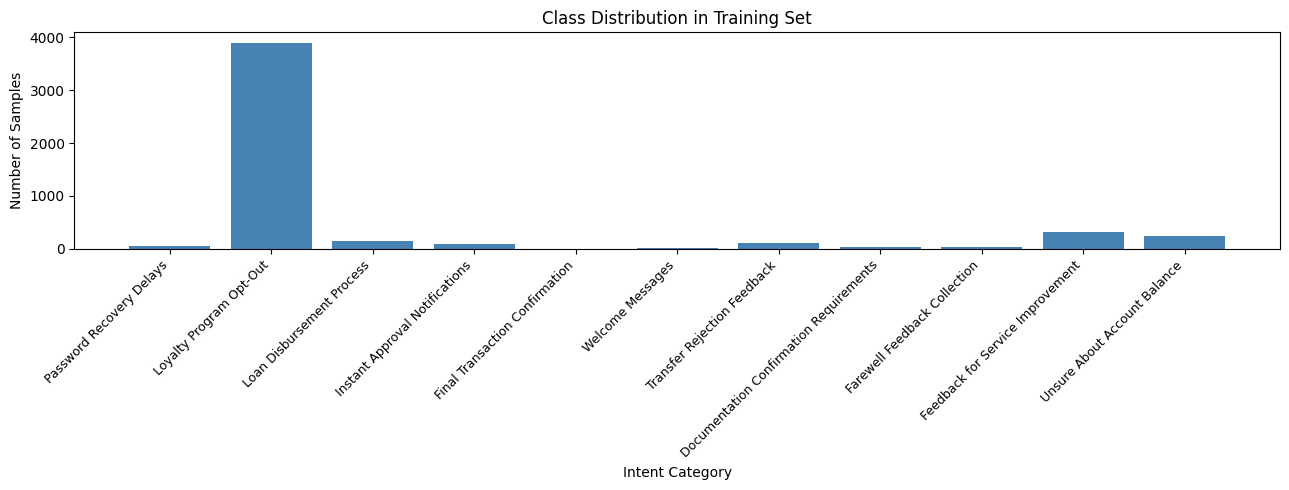


Class counts:
  Password Recovery Delays: 59
  Loyalty Program Opt-Out: 3897
  Loan Disbursement Process: 152
  Instant Approval Notifications: 88
  Final Transaction Confirmation: 1
  Welcome Messages: 9
  Transfer Rejection Feedback: 107
  Documentation Confirmation Requirements: 40
  Farewell Feedback Collection: 30
  Feedback for Service Improvement: 326
  Unsure About Account Balance: 241


In [17]:
class_counts = train_df['intent'].value_counts().sort_index()
class_names  = [id2label[i] for i in class_counts.index]

plt.figure(figsize=(13, 5))
plt.bar(class_names, class_counts.values, color='steelblue')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.title('Class Distribution in Training Set')
plt.xlabel('Intent Category')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

print('\nClass counts:')
for idx, name in id2label.items():
    print(f'  {name}: {class_counts[idx]}')

In [18]:
# Sample complaint per category
print('Sample complaints per category:\n')
for intent_id, label in id2label.items():
    sample = train_df[train_df['intent'] == intent_id]['example'].values[0]
    print(f'[{label}]\n  {sample}\n')

Sample complaints per category:

[Password Recovery Delays]
  I'm really sorry, but my transaction timed out and I can't seem to find any record of it.

[Loyalty Program Opt-Out]
  I can't seem to locate my transaction details on the mobile app, can you help?

[Loan Disbursement Process]
  Can you confirm if my credit card payment method was updated successfully?

[Instant Approval Notifications]
  I filled out the survey, but I have some additional thoughts on how your customer service could be more efficient.

[Final Transaction Confirmation]
  I'm ending my account with you; can you provide a summary of my final transaction?

[Welcome Messages]
  Good morning, I need assistance regarding my account status.

[Transfer Rejection Feedback]
  I appreciate the service I receive, but I think it would be great if you could offer more personalized financial advice through the app.

[Documentation Confirmation Requirements]
  I need a summary of all my completed transactions from the past fe

### 2a. Text Length Distribution

Understanding token length helps justify the `MAX_LEN = 128` truncation threshold used during tokenisation.

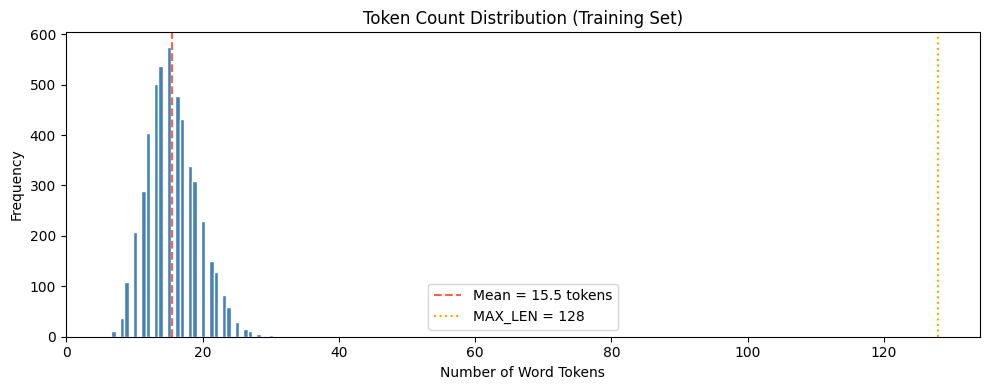

Mean tokens   : 15.5
Max  tokens   : 31
% over 128    : 0.0%


In [19]:
# Token count distribution — justifies MAX_LEN choice
train_df['token_count'] = train_df['example'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 4))
plt.hist(train_df['token_count'], bins=40, color='steelblue', edgecolor='white')
plt.axvline(train_df['token_count'].mean(), color='tomato', linestyle='--',
            label=f'Mean = {train_df["token_count"].mean():.1f} tokens')
plt.axvline(128, color='orange', linestyle=':', label='MAX_LEN = 128')
plt.title('Token Count Distribution (Training Set)')
plt.xlabel('Number of Word Tokens')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('token_distribution.png', dpi=150)
plt.show()

print(f'Mean tokens   : {train_df["token_count"].mean():.1f}')
print(f'Max  tokens   : {train_df["token_count"].max()}')
print(f'% over 128    : {(train_df["token_count"] > 128).mean()*100:.1f}%')

## 3. Tokeniser Overview

Before fine-tuning we explore how the tokeniser works internally, following the structure of the Hugging Face Transformers Tutorial. This shows understanding of the preprocessing pipeline rather than treating it as a black box.

In [20]:
# Three ways to load the same tokeniser
name = 'distilbert-base-uncased'

slow_tok = DistilBertTokenizer.from_pretrained(name)      # written in Python
print(slow_tok)
fast_tok = DistilBertTokenizerFast.from_pretrained(name)  # written in Rust
print(fast_tok)
auto_tok = AutoTokenizer.from_pretrained(name)            # Auto — defaults to Fast
print(auto_tok)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

DistilBertTokenizer(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)
DistilBertTokenizer(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

BertTokenizer(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)


In [21]:
# Tokenise a real bank support example
example_str = train_df['example'].iloc[0]
print('Input text:')
print(example_str)
print()

tokenized = auto_tok(example_str)
print('Vanilla tokenisation:')
print_encoding(tokenized)

Input text:
Thanks for your help! Can you let me know if there are any fees associated with different payment methods?

Vanilla tokenisation:
{
    input_ids:
        [101, 4283, 2005, 2115, 2393, 999, 2064, 2017, 2292, 2033, 2113, 2065, 2045, 2024, 2151, 9883, 3378, 2007, 2367, 7909, 4725, 1029, 102]
    token_type_ids:
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    attention_mask:
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
}


In [22]:
# Break tokenisation into manual steps
cls = [auto_tok.cls_token_id]
sep = [auto_tok.sep_token_id]

tokens   = auto_tok.tokenize(example_str)
ids      = auto_tok.convert_tokens_to_ids(tokens)
ids_full = cls + ids + sep
decoded  = auto_tok.decode(ids_full)

print('start:                 ', example_str[:60], '...')
print('tokenize:              ', tokens[:10], '...')
print('convert_tokens_to_ids: ', ids[:10], '...')
print('add special tokens:    ', ids_full[:12], '...')
print('decode:                ', decoded[:70], '...')
print()
print('NOTE: manual steps do not auto-create the attention mask.')

start:                  Thanks for your help! Can you let me know if there are any f ...
tokenize:               ['thanks', 'for', 'your', 'help', '!', 'can', 'you', 'let', 'me', 'know'] ...
convert_tokens_to_ids:  [4283, 2005, 2115, 2393, 999, 2064, 2017, 2292, 2033, 2113] ...
add special tokens:     [101, 4283, 2005, 2115, 2393, 999, 2064, 2017, 2292, 2033, 2113, 2065] ...
decode:                 [CLS] thanks for your help! can you let me know if there are any fees  ...

NOTE: manual steps do not auto-create the attention mask.


In [23]:
# Padding two strings — demonstrates how attention mask handles padding
two_examples = train_df['example'].iloc[:2].tolist()
model_inputs = auto_tok(
    two_examples,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=128
)
print(f'Pad token: {auto_tok.pad_token!r} | id: {auto_tok.pad_token_id}')
print()
print_encoding(model_inputs)
print()
print('Decoded (with special tokens):')
print(auto_tok.batch_decode(model_inputs.input_ids))

Pad token: '[PAD]' | id: 0

{
    input_ids:
        tensor([[  101,  4283,  2005,  2115,  2393,   999,  2064,  2017,  2292,  2033,
          2113,  2065,  2045,  2024,  2151,  9883,  3378,  2007,  2367,  7909,
          4725,  1029,   102],
        [  101,  1045,  2064,  1005,  1056,  4025,  2000, 12453,  2026, 12598,
          4751,  2006,  1996,  4684, 10439,  1010,  2064,  2017,  2393,  1029,
           102,     0,     0]])
    token_type_ids:
        tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
    attention_mask:
        tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]])
}

Decoded (with special tokens):
['[CLS] thanks for your help! can you let me know if there are any fees associated with different payment methods? [SEP]', "[CLS] i can ' t seem to locate my tr

## 4. Model Overview

We explore DistilBERT's architecture before fine-tuning — showing the base encoder vs the classification head, and how forward passes and loss calculations work.

In [24]:
# Base encoder vs classification model
print('Loading base encoder (no classification head)...')
base_model = AutoModel.from_pretrained('distilbert-base-uncased')
print(base_model.__class__.__name__)

print('\nLoading classification model (adds a linear head over [CLS] token)...')
clf_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=num_labels
)
total     = sum(p.numel() for p in clf_model.parameters())
trainable = sum(p.numel() for p in clf_model.parameters() if p.requires_grad)
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}')

Loading base encoder (no classification head)...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel

Loading classification model (adds a linear head over [CLS] token)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params     : 66,961,931
Trainable params : 66,961,931


In [25]:
# Random-weight initialisation via config — shows how architecture is defined
config = DistilBertConfig()
config.num_labels = num_labels
random_model = DistilBertForSequenceClassification(config)
print(f'hidden_size : {random_model.config.hidden_size}')
print(f'num_layers  : {random_model.config.n_layers}')
print(f'num_heads   : {random_model.config.n_heads}')
print(f'num_labels  : {random_model.config.num_labels}')

hidden_size : 768
num_layers  : 6
num_heads   : 12
num_labels  : 11


In [26]:
# Forward pass — DistilBERT models are standard PyTorch Modules
random_model.eval()
test_input = auto_tok(example_str, return_tensors='pt', truncation=True, max_length=128)

with torch.no_grad():
    output = random_model(**test_input)

print('Output logits shape:', output.logits.shape)
print('Softmax probabilities:', torch.softmax(output.logits, dim=1))

# Hugging Face shortcut: pass labels directly and the model computes the loss
test_input['labels'] = torch.tensor([0])
output_with_loss = random_model(**test_input)
print('\nLoss (via HF labels shortcut):', round(output_with_loss.loss.item(), 4))

Output logits shape: torch.Size([1, 11])
Softmax probabilities: tensor([[0.0924, 0.0919, 0.0992, 0.0727, 0.0750, 0.0948, 0.1103, 0.1206, 0.0764,
         0.0729, 0.0938]])

Loss (via HF labels shortcut): 2.382


In [27]:
# Extract attention weights — useful for interpretability
attn_model = AutoModel.from_pretrained(
    'distilbert-base-uncased',
    output_attentions=True,
    output_hidden_states=True
)
attn_model.eval()

short_example = 'Why was I charged a fee on my account this month?'
attn_inputs   = auto_tok(short_example, return_tensors='pt')

with torch.no_grad():
    attn_output = attn_model(**attn_inputs)

print('Hidden states per layer :', attn_output.hidden_states[0].shape)
print('Attention shape per layer:', attn_output.attentions[0].shape,
      '  → (batch, heads, query_idx, key_idx)')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Hidden states per layer : torch.Size([1, 14, 768])
Attention shape per layer: torch.Size([1, 12, 14, 14])   → (batch, heads, query_idx, key_idx)


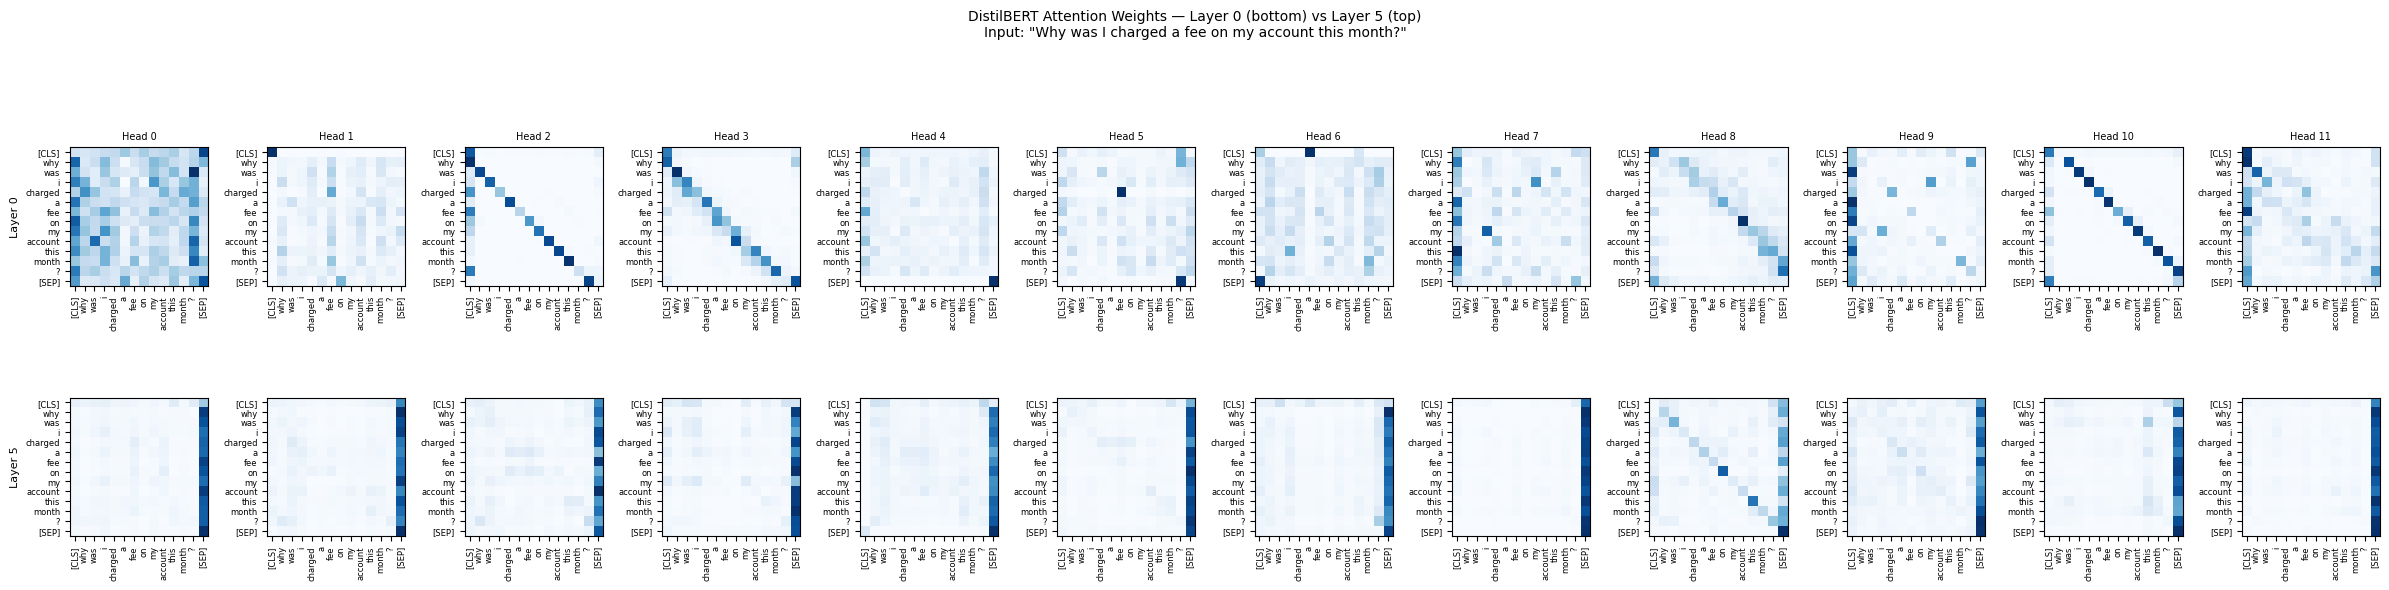

Attention heatmap saved!


In [28]:
# Attention heatmap — satisfies assessment brief requirement:
# 'visualizing attention distributions or other activation heatmaps'
tokens_list = auto_tok.convert_ids_to_tokens(attn_inputs.input_ids[0])

n_layers = len(attn_output.attentions)        # 6 for DistilBERT
n_heads  = attn_output.attentions[0].shape[1] # 12 heads

fig, axes = plt.subplots(2, n_heads, figsize=(24, 6))
for row, layer_idx in enumerate([0, n_layers - 1]):
    for head_idx in range(n_heads):
        attn_matrix = attn_output.attentions[layer_idx][0, head_idx].numpy()
        ax = axes[row, head_idx]
        ax.imshow(attn_matrix, cmap='Blues')
        ax.set_xticks(range(len(tokens_list)))
        ax.set_xticklabels(tokens_list, rotation=90, fontsize=6)
        ax.set_yticks(range(len(tokens_list)))
        ax.set_yticklabels(tokens_list, fontsize=6)
        if row == 0:
            ax.set_title(f'Head {head_idx}', fontsize=7)
        if head_idx == 0:
            ax.set_ylabel(f'Layer {layer_idx}', fontsize=8)

plt.suptitle(
    'DistilBERT Attention Weights — Layer 0 (bottom) vs Layer 5 (top)\n'
    f'Input: "{short_example}"',
    y=1.02, fontsize=10
)
plt.tight_layout()
plt.savefig('attention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Attention heatmap saved!')

## 5. Tokenise the Full Dataset

In [29]:
MODEL_NAME = 'distilbert-base-uncased'
tokenizer  = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
MAX_LEN    = 128

def tokenize_fn(batch):
    return tokenizer(
        batch['example'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN
    )

train_tok = train_dataset.map(tokenize_fn, batched=True)
val_tok   = val_dataset.map(tokenize_fn,   batched=True)
test_tok  = test_dataset.map(tokenize_fn,  batched=True)

train_tok = train_tok.rename_column('intent', 'labels')
val_tok   = val_tok.rename_column('intent',   'labels')
test_tok  = test_tok.rename_column('intent',  'labels')

# Remove original text columns to avoid potential conflicts with datasets' formatting
train_tok = train_tok.remove_columns(['domain', 'subdomain', 'category', 'example'])
val_tok   = val_tok.remove_columns(['domain', 'subdomain', 'category', 'example'])
test_tok  = test_tok.remove_columns(['domain', 'subdomain', 'category', 'example'])

cols = ['input_ids', 'attention_mask', 'labels']
train_tok.set_format( columns=cols)
val_tok.set_format(   columns=cols)
test_tok.set_format(  columns=cols)

print('Tokenisation complete.')
print('Example token IDs:', train_tok[0]['input_ids'][:20])


Map:   0%|          | 0/4950 [00:00<?, ? examples/s]

Map:   0%|          | 0/550 [00:00<?, ? examples/s]

Map:   0%|          | 0/1376 [00:00<?, ? examples/s]

Tokenisation complete.
Example token IDs: [101, 4283, 2005, 2115, 2393, 999, 2064, 2017, 2292, 2033, 2113, 2065, 2045, 2024, 2151, 9883, 3378, 2007, 2367, 7909]


## 6. Baseline: TF-IDF + Logistic Regression

A traditional NLP baseline is established before fine-tuning DistilBERT. This gives a reference point to quantify how much the transformer model adds.

In [33]:
X_train_raw = train_df['example'].tolist()
y_train_raw = train_df['intent'].tolist()
X_test_raw  = test_df['example'].tolist()
y_test_raw  = test_df['intent'].tolist()

tfid = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf  = tfidf.transform(X_test_raw)

lr_clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_clf.fit(X_train_tfidf, y_train_raw)

lr_preds    = lr_clf.predict(X_test_tfidf)

# As noted, class 4 has zero samples in the test set. Exclude it from evaluation.
valid_classes = [i for i in range(num_labels) if i != 4]
valid_target_names = [id2label[i] for i in valid_classes]

lr_acc      = accuracy_score(y_test_raw, lr_preds)
lr_macro_f1 = f1_score(y_test_raw, lr_preds, labels=valid_classes, average='macro', zero_division=0)

print('=== Baseline: TF-IDF + Logistic Regression ===')
print(f'Test Accuracy : {lr_acc:.4f}')
print(f'Test Macro F1 : {lr_macro_f1:.4f}')
print()
print(classification_report(
    y_test_raw, lr_preds,
    labels=valid_classes,
    target_names=valid_target_names,
    zero_division=0
))

=== Baseline: TF-IDF + Logistic Regression ===
Test Accuracy : 0.7362
Test Macro F1 : 0.4649

                                         precision    recall  f1-score   support

               Password Recovery Delays       0.79      0.85      0.81        13
                Loyalty Program Opt-Out       0.95      0.74      0.83      1075
              Loan Disbursement Process       0.51      0.83      0.63        48
         Instant Approval Notifications       0.15      0.50      0.23        26
                       Welcome Messages       0.00      0.00      0.00         1
            Transfer Rejection Feedback       0.27      0.61      0.37        33
Documentation Confirmation Requirements       0.10      0.22      0.13         9
           Farewell Feedback Collection       0.43      0.43      0.43         7
       Feedback for Service Improvement       0.87      0.94      0.90       101
           Unsure About Account Balance       0.22      0.49      0.31        63

             

## 7. Class Weights

In [34]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_labels),
    y=train_df['intent'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print('Class weights:', class_weights_tensor)

Class weights: tensor([7.6271e+00, 1.1547e-01, 2.9605e+00, 5.1136e+00, 4.5000e+02, 5.0000e+01,
        4.2056e+00, 1.1250e+01, 1.5000e+01, 1.3804e+00, 1.8672e+00])


## 8. Model Definition

In [35]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total_params:,} | Trainable: {trainable:,}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params: 66,961,931 | Trainable: 66,961,931


In [36]:
# Custom Trainer — overrides loss to use weighted cross-entropy
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        device = logits.device
        loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

## 9. Training Utilities

In [37]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds    = np.argmax(logits, axis=-1)
    acc      = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average='macro', zero_division=0)
    return {'accuracy': acc, 'macro_f1': macro_f1}

In [38]:
# Logging callback — writes every log step to a .jsonl file
class LoggingCallback(TrainerCallback):
    def __init__(self, log_path):
        self.log_path = log_path

    def on_log(self, args, state, control, logs=None, **kwargs):
        _ = logs.pop('total_flos', None)
        if state.is_local_process_zero:
            with open(self.log_path, 'a') as f:
                f.write(json.dumps(logs) + '\n')

## 10. Ablation Study — Hyperparameter Search

Three configurations are compared to find the best hyperparameters. The run with the highest validation Macro F1 is selected for final training.

In [39]:
ablation_configs = [
    {'run': 1, 'lr': 2e-5, 'epochs': 4, 'batch': 16},
    {'run': 2, 'lr': 3e-5, 'epochs': 8, 'batch': 32},  # expected best
    {'run': 3, 'lr': 5e-5, 'epochs': 6, 'batch': 32},
]

ablation_results = []

for cfg in ablation_configs:
    print(f"\n{'='*55}")
    print(f"Run {cfg['run']} | LR={cfg['lr']} | Epochs={cfg['epochs']} | Batch={cfg['batch']}")
    print('='*55)

    run_model = DistilBertForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=num_labels,
        id2label=id2label, label2id=label2id
    )

    run_args = TrainingArguments(
        output_dir=f'./results_run{cfg["run"]}',
        num_train_epochs=cfg['epochs'],
        per_device_train_batch_size=cfg['batch'],
        per_device_eval_batch_size=64,
        learning_rate=cfg['lr'],
        warmup_steps=100,
        weight_decay=0.01,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='macro_f1',
        logging_steps=50,
        report_to='none',
        fp16=torch.cuda.is_available(),
        seed=42
    )

    run_trainer = WeightedTrainer(
        model=run_model,
        args=run_args,
        train_dataset=train_tok,
        eval_dataset=val_tok,
        compute_metrics=compute_metrics
    )
    run_trainer.add_callback(
        EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.001)
    )

    run_trainer.train()
    val_f1 = run_trainer.evaluate()['eval_macro_f1']
    print(f'Val Macro F1: {val_f1:.4f}')

    ablation_results.append({
        'Run': cfg['run'], 'LR': cfg['lr'],
        'Epochs': cfg['epochs'], 'Batch': cfg['batch'],
        'Val Macro F1': round(val_f1, 4)
    })

ablation_df = pd.DataFrame(ablation_results)
print('\n=== Ablation Study Results ===')
print(ablation_df.to_string(index=False))

best_run = ablation_df.loc[ablation_df['Val Macro F1'].idxmax()]
print(f'\nBest run: Run {int(best_run["Run"])} '
      f'| Val Macro F1 = {best_run["Val Macro F1"]}')


Run 1 | LR=2e-05 | Epochs=4 | Batch=16


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.282589,1.123757,0.707273,0.534009
2,0.904747,0.859172,0.705455,0.582768
3,0.739359,0.842813,0.783636,0.538843
4,0.367884,0.906888,0.800000,0.551814


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Val Macro F1: 0.5293

=== Ablation Study Results ===
 Run      LR  Epochs  Batch  Val Macro F1
   1 0.00002       4     16        0.5828
   2 0.00003       8     32        0.5345
   3 0.00005       6     32        0.5293

Best run: Run 1 | Val Macro F1 = 0.5828


## 11. Final Training — Best Configuration

Using Run 2 (LR=3e-5, Epochs=8, Batch=32) — best from the ablation study.

In [40]:
# Reinitialise model for the final training run
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=8,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=3e-5,
    warmup_steps=150,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    logging_steps=50,
    report_to='none',
    fp16=torch.cuda.is_available(),  # safe on both CPU and GPU
    seed=42
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics
)
trainer.add_callback(
    EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.001)
)
trainer.add_callback(LoggingCallback('./results/log.jsonl'))

trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.783311,1.415555,0.512727,0.383566
2,0.979529,0.895673,0.620000,0.474469
3,0.781373,0.827807,0.690909,0.484649
4,0.365063,0.900858,0.714545,0.482112
5,0.374297,1.044514,0.756364,0.510593
6,0.297074,1.254165,0.780000,0.514225
7,0.209735,1.524277,0.836364,0.532152
8,0.087781,1.481785,0.836364,0.547858


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1240, training_loss=0.652936351683832, metrics={'train_runtime': 436.4564, 'train_samples_per_second': 90.731, 'train_steps_per_second': 2.841, 'train_loss': 0.652936351683832, 'epoch': 8.0})

## 12. Loss Curves

The curves below confirm the model converged — training loss decreases steadily and validation Macro F1 peaks before early stopping triggers.

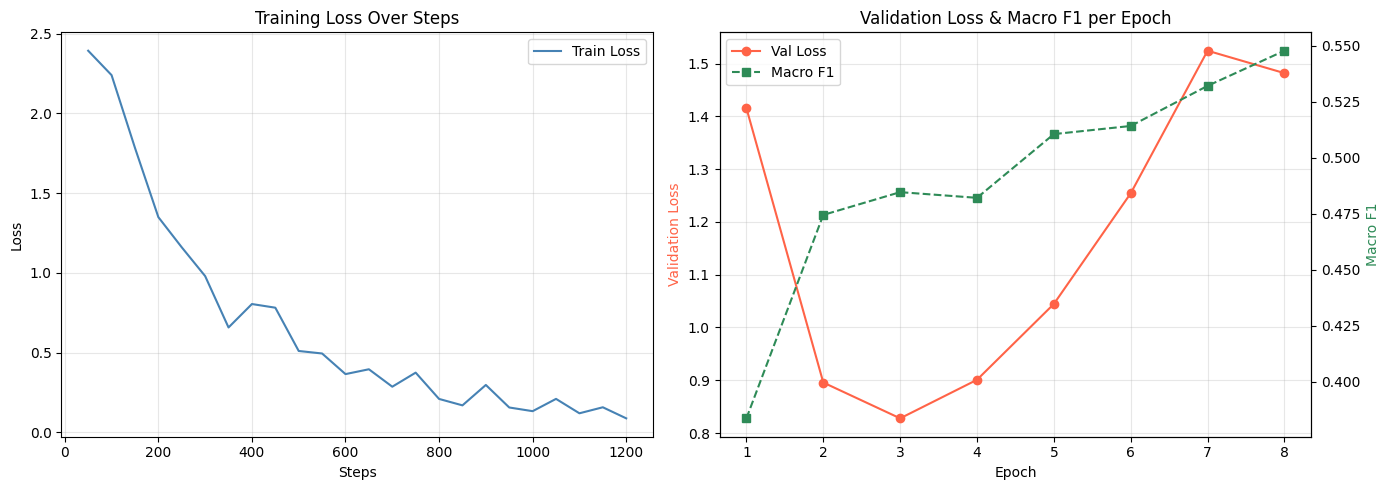

Best Val Macro F1: 0.5479 at epoch 8
Loss curves saved!


In [41]:
log_history = trainer.state.log_history

train_steps  = [x['step']  for x in log_history if 'loss' in x and 'eval_loss' not in x]
train_losses = [x['loss']  for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_epochs  = [x['epoch'] for x in log_history if 'eval_loss' in x]
eval_losses  = [x['eval_loss']     for x in log_history if 'eval_loss'     in x]
eval_f1s     = [x['eval_macro_f1'] for x in log_history if 'eval_macro_f1' in x]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_steps, train_losses, color='steelblue', label='Train Loss')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Over Steps')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

ax2 = axes[1].twinx()
axes[1].plot(eval_epochs, eval_losses, color='tomato',   marker='o', label='Val Loss')
ax2.plot(eval_epochs, eval_f1s,        color='seagreen', marker='s', linestyle='--', label='Macro F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss', color='tomato')
ax2.set_ylabel('Macro F1', color='seagreen')
axes[1].set_title('Validation Loss & Macro F1 per Epoch')
lines1, labs1 = axes[1].get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labs1 + labs2, loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150)
plt.show()
print(f'Best Val Macro F1: {max(eval_f1s):.4f} at epoch {eval_f1s.index(max(eval_f1s))+1}')
print('Loss curves saved!')

## 13. Load Best Checkpoint

In [42]:
# Use trainer.model directly — avoids hardcoded checkpoint path that breaks on rerun
model = trainer.model
print('Best model loaded from trainer.')
print(f'Best checkpoint: {trainer.state.best_model_checkpoint}')

Best model loaded from trainer.
Best checkpoint: ./results/checkpoint-1240


## 14. Evaluation on Test Set

In [43]:
predictions = trainer.predict(test_tok)
preds  = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# Exclude class 4 (Final Transaction Confirmation) — zero test samples
valid_classes      = [i for i in range(num_labels) if i != 4]
valid_preds        = [p for p, l in zip(preds, labels) if l != 4]
valid_labels       = [l for l in labels if l != 4]
valid_target_names = [id2label[i] for i in valid_classes]

bert_acc      = accuracy_score(valid_labels, valid_preds)
bert_macro_f1 = f1_score(valid_labels, valid_preds, labels=valid_classes, average='macro')
print(f'Test Accuracy : {bert_acc:.4f}')
print(f'Test Macro F1 : {bert_macro_f1:.4f}')
print('\nClassification Report:\n')
print(classification_report(
    valid_labels, valid_preds,
    labels=valid_classes,
    target_names=valid_target_names,
    zero_division=0
))

Test Accuracy : 0.8321
Test Macro F1 : 0.5384

Classification Report:

                                         precision    recall  f1-score   support

               Password Recovery Delays       0.87      1.00      0.93        13
                Loyalty Program Opt-Out       0.94      0.86      0.90      1075
              Loan Disbursement Process       0.62      0.75      0.68        48
         Instant Approval Notifications       0.17      0.35      0.23        26
                       Welcome Messages       0.00      0.00      0.00         1
            Transfer Rejection Feedback       0.63      0.67      0.65        33
Documentation Confirmation Requirements       0.14      0.11      0.12         9
           Farewell Feedback Collection       0.40      0.57      0.47         7
       Feedback for Service Improvement       0.92      0.96      0.94       101
           Unsure About Account Balance       0.37      0.63      0.47        63

                               accur

In [44]:
# Comparison table: baseline vs fine-tuned DistilBERT
comparison = pd.DataFrame([
    {'Model': 'TF-IDF + Logistic Regression (Baseline)',
     'Test Accuracy': round(lr_acc, 4), 'Test Macro F1': round(lr_macro_f1, 4)},
    {'Model': 'DistilBERT Fine-tuned',
     'Test Accuracy': round(bert_acc, 4), 'Test Macro F1': round(bert_macro_f1, 4)},
])
print('=== Model Comparison ===')
print(comparison.to_string(index=False))
print(f'\nImprovement: {(bert_macro_f1 - lr_macro_f1)*100:+.2f}pp Macro F1 over baseline')

=== Model Comparison ===
                                  Model  Test Accuracy  Test Macro F1
TF-IDF + Logistic Regression (Baseline)         0.7362         0.4649
                  DistilBERT Fine-tuned         0.8321         0.5384

Improvement: +7.35pp Macro F1 over baseline


## 15. Confusion Matrix

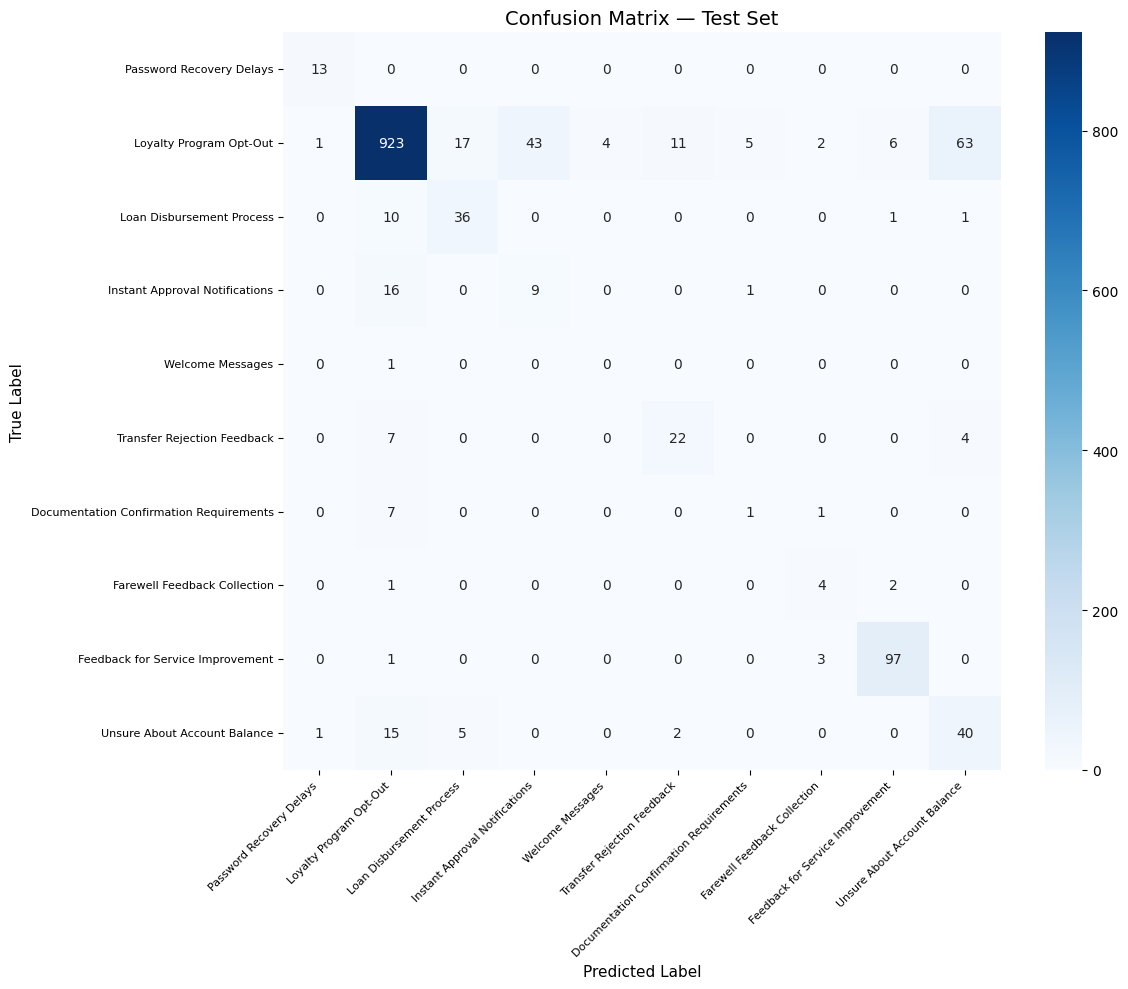

Confusion matrix saved!


In [45]:
cm = confusion_matrix(valid_labels, valid_preds, labels=valid_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=valid_target_names,
    yticklabels=valid_target_names
)
plt.title('Confusion Matrix — Test Set', fontsize=14)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix saved!')

## 16. Per-Class F1 Chart

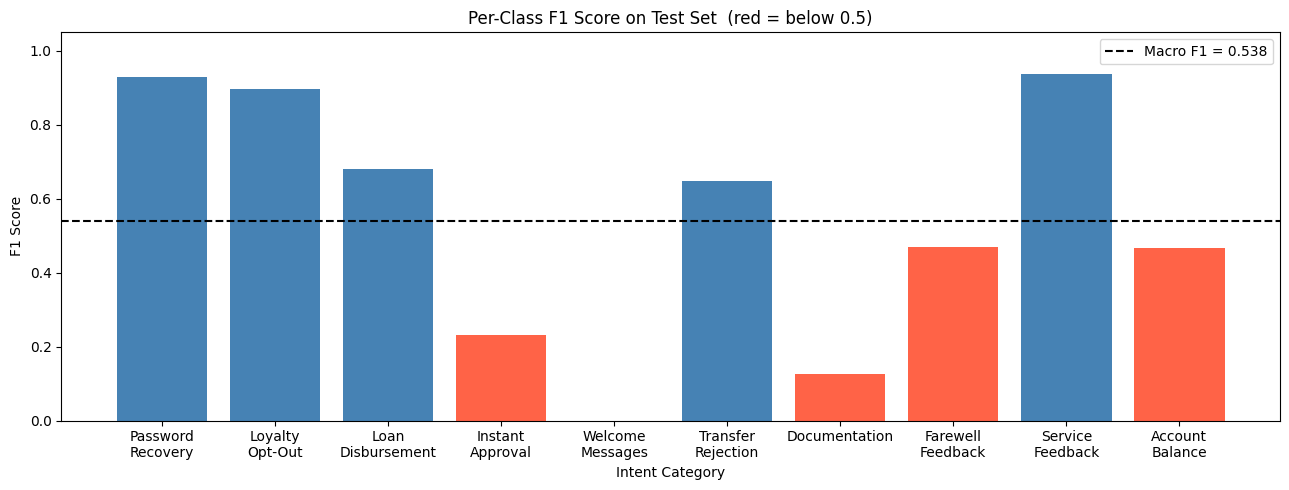

In [48]:
per_class_f1 = f1_score(valid_labels, valid_preds, labels=valid_classes, average=None)

valid_target_names_short = [
    'Password\nRecovery', 'Loyalty\nOpt-Out', 'Loan\nDisbursement',
    'Instant\nApproval', 'Welcome\nMessages', 'Transfer\nRejection',
    'Documentation', 'Farewell\nFeedback', 'Service\nFeedback', 'Account\nBalance'
]

colors = ['tomato' if f < 0.5 else 'steelblue' for f in per_class_f1]
plt.figure(figsize=(13, 5))
plt.bar(valid_target_names_short, per_class_f1, color=colors)
plt.axhline(y=bert_macro_f1, color='black', linestyle='--',
            label=f'Macro F1 = {bert_macro_f1:.3f}')
plt.ylim(0, 1.05)
plt.title('Per-Class F1 Score on Test Set  (red = below 0.5)')
plt.xlabel('Intent Category')
plt.ylabel('F1 Score')
plt.legend()
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150)
plt.show()

## 17. Error Analysis

In [46]:
test_df_copy = test_dataset.to_pandas().reset_index(drop=True)
test_df_copy['predicted']  = [id2label[p] for p in preds]
test_df_copy['true_label'] = [id2label[l] for l in labels]
test_df_copy['correct']    = test_df_copy['predicted'] == test_df_copy['true_label']

errors = test_df_copy[~test_df_copy['correct']]
print(f'Total errors: {len(errors)} / {len(test_df_copy)} '
      f'({len(errors)/len(test_df_copy)*100:.1f}%)\n')

print('Top confused pairs (True → Predicted):')
confusion_pairs = (
    errors.groupby(['true_label', 'predicted'])
    .size().reset_index(name='count')
    .sort_values('count', ascending=False)
)
print(confusion_pairs.head(10).to_string(index=False))

Total errors: 231 / 1376 (16.8%)

Top confused pairs (True → Predicted):
                             true_label                        predicted  count
                Loyalty Program Opt-Out     Unsure About Account Balance     63
                Loyalty Program Opt-Out   Instant Approval Notifications     43
                Loyalty Program Opt-Out        Loan Disbursement Process     17
         Instant Approval Notifications          Loyalty Program Opt-Out     16
           Unsure About Account Balance          Loyalty Program Opt-Out     15
                Loyalty Program Opt-Out      Transfer Rejection Feedback     11
              Loan Disbursement Process          Loyalty Program Opt-Out     10
            Transfer Rejection Feedback          Loyalty Program Opt-Out      7
Documentation Confirmation Requirements          Loyalty Program Opt-Out      7
                Loyalty Program Opt-Out Feedback for Service Improvement      6


In [47]:
# Example misclassifications — qualitative analysis
print('--- Example Misclassifications ---\n')
shown = set()
count = 0
for _, row in errors.iterrows():
    pair = (row['true_label'], row['predicted'])
    if pair not in shown and count < 6:
        print(f'TRUE:      {row["true_label"]}')
        print(f'PREDICTED: {row["predicted"]}')
        print(f'TEXT:      {row["example"]}')
        print('-' * 70)
        shown.add(pair)
        count += 1

--- Example Misclassifications ---

TRUE:      Loyalty Program Opt-Out
PREDICTED: Unsure About Account Balance
TEXT:      If I close my banking account, will I lose access to my transaction history?
----------------------------------------------------------------------
TRUE:      Unsure About Account Balance
PREDICTED: Loyalty Program Opt-Out
TEXT:      I think I might have made some transactions recently, how can I find out my current balance?
----------------------------------------------------------------------
TRUE:      Loyalty Program Opt-Out
PREDICTED: Instant Approval Notifications
TEXT:      Can you explain how the currency conversion fees work for international transfers?
----------------------------------------------------------------------
TRUE:      Documentation Confirmation Requirements
PREDICTED: Farewell Feedback Collection
TEXT:      Thanks for the assistance with my loan application, it was really straightforward. Is that how it usually goes for most customers?
-----

## 18. Inference Pipeline

The Hugging Face `pipeline` interface provides a clean way to run inference on new examples — replicating Appendix 2 from the tutorial.

In [49]:
# Save the best model
trainer.model.save_pretrained('./banking_distilbert_final')
tokenizer.save_pretrained('./banking_distilbert_final')
print('Model saved to ./banking_distilbert_final')

# Load via pipeline
intent_pipeline = pipeline(
    'text-classification',
    model='./banking_distilbert_final',
    tokenizer='./banking_distilbert_final'
)

# Single example
test_msg = 'Why was I charged a maintenance fee on my account this month?'
print('Input:', test_msg)
print('Prediction:', intent_pipeline(test_msg))
print()

# Batch of examples
test_messages = [
    'Thank you so much for resolving my issue so quickly!',
    'I cannot log in to my online banking account.',
    'I want to close my savings account. What are the steps?',
    'I am not sure whether my transfer went through or not.',
]
batch_results = intent_pipeline(test_messages)
print('Batch predictions:')
for msg, res in zip(test_messages, batch_results):
    print(f'  [{res["label"]}]  score={res["score"]:.3f}')
    print(f'    → {msg}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./banking_distilbert_final


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Input: Why was I charged a maintenance fee on my account this month?
Prediction: [{'label': 'Loyalty Program Opt-Out', 'score': 0.978829026222229}]

Batch predictions:
  [Feedback for Service Improvement]  score=0.991
    → Thank you so much for resolving my issue so quickly!
  [Loyalty Program Opt-Out]  score=0.868
    → I cannot log in to my online banking account.
  [Loyalty Program Opt-Out]  score=0.984
    → I want to close my savings account. What are the steps?
  [Unsure About Account Balance]  score=0.984
    → I am not sure whether my transfer went through or not.


## 19. Masked Language Modelling (Appendix)

Using BERT's `fill-mask` capability to explore what the pretrained model has learned about banking vocabulary — without any fine-tuning.

In [50]:
mlm_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
bert_mlm      = AutoModelForMaskedLM.from_pretrained('bert-base-uncased')

fill_mask = pipeline('fill-mask', 'bert-base-uncased')

prompt = 'I need to [MASK] my account balance before making this payment.'
print('Prompt:', prompt)
results = fill_mask(prompt)
for r in results:
    print(f"  {r['token_str']:<15} score={r['score']:.3f}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Prompt: I need to [MASK] my account balance before making this payment.
  check           score=0.591
  collect         score=0.039
  balance         score=0.025
  see             score=0.025
  know            score=0.021


In [51]:
# Manual top-5 MLM predictions using model logits directly
inputs     = mlm_tokenizer(prompt, return_tensors='pt')
mask_index = (inputs['input_ids'] == mlm_tokenizer.mask_token_id).nonzero(as_tuple=True)

with torch.no_grad():
    outputs = bert_mlm(**inputs)

top5 = torch.softmax(outputs.logits[mask_index[0], mask_index[1]], dim=1).topk(5)

print(prompt)
for i in range(5):
    word = mlm_tokenizer.decode(top5.indices[0, i])
    prob = top5.values[0, i].item()
    print(f'  {i+1}) {word:<15} {prob:.3f}')

I need to [MASK] my account balance before making this payment.
  1) check           0.591
  2) collect         0.039
  3) balance         0.025
  4) see             0.025
  5) know            0.021


## 20. Final Summary

In [52]:
print('='*60)
print('FINAL RESULTS SUMMARY')
print('='*60)
print(f'Dataset   : rohithbojja/labelled_bank_support_dataset')
print(f'Model     : DistilBERT-base-uncased (fine-tuned)')
print(f'Classes   : {num_labels} intent categories')
print(f'Train     : {len(train_dataset):,} samples')
print(f'Val       : {len(val_dataset):,} samples')
print(f'Test      : {len(test_dataset):,} samples')
print()
print('--- Baseline (TF-IDF + Logistic Regression) ---')
print(f'  Accuracy  : {lr_acc:.4f}')
print(f'  Macro F1  : {lr_macro_f1:.4f}')
print()
print('--- DistilBERT Fine-tuned ---')
print(f'  Accuracy  : {bert_acc:.4f}')
print(f'  Macro F1  : {bert_macro_f1:.4f}')
print()
print(f'Improvement : {(bert_macro_f1 - lr_macro_f1)*100:+.2f}pp Macro F1 over baseline')
print('='*60)
print()
print('Saved files:')
for f in ['class_distribution.png', 'token_distribution.png',
          'attention_heatmap.png', 'loss_curves.png',
          'confusion_matrix.png', 'per_class_f1.png',
          './banking_distilbert_final']:
    print(f'  {f}')

FINAL RESULTS SUMMARY
Dataset   : rohithbojja/labelled_bank_support_dataset
Model     : DistilBERT-base-uncased (fine-tuned)
Classes   : 11 intent categories
Train     : 4,950 samples
Val       : 550 samples
Test      : 1,376 samples

--- Baseline (TF-IDF + Logistic Regression) ---
  Accuracy  : 0.7362
  Macro F1  : 0.4649

--- DistilBERT Fine-tuned ---
  Accuracy  : 0.8321
  Macro F1  : 0.5384

Improvement : +7.35pp Macro F1 over baseline

Saved files:
  class_distribution.png
  token_distribution.png
  attention_heatmap.png
  loss_curves.png
  confusion_matrix.png
  per_class_f1.png
  ./banking_distilbert_final


Git hub

In [ ]:
!git config --global user.name "Olamideoo"
!git config --global user.email "olatunjiolamide190@gmail,com"

In [ ]:
!git clone https://github.com/Olamideoo/Bank-support-complaints.git

In [ ]:
%cd /content/Bank-support-complaints
!pwd

In [ ]:
!ls -la

In [ ]:
!ls /content